# Supervised Learning



##  Understand the ML Problem

**Problem statement:** A botanical organization wants to automatically classify iris flowers into their
correct species based only on four physical measurements.

**Input (features):**
- Sepal Length (cm)
- Sepal Width (cm)
- Petal Length (cm)
- Petal Width (cm)

**Output (target):**
- Species — one of three categories: *setosa*, *versicolor*, *virginica*


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Reproducibility: fixing the random seed ensures our results
# (train/test splits, etc.) are the same every time we run the notebook.
RANDOM_STATE = 42


print("Libraries imported successfully.")


Libraries imported successfully.


## Section 4 — Load the Dataset




In [3]:
iris = load_iris()

In [4]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [6]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [7]:
iris.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [9]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [10]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [16]:
# target labels
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

### Let's make pd df

In [11]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)

In [12]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [17]:
df["species_code"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [35]:
df["species"] = iris.target_names[iris.target]

## Section 5 — First Data Inspection




In [36]:
# First 5 rows - a quick visual sanity check of the data
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code,species
0,5.1,3.5,1.4,0.2,0.0,setosa
1,4.9,3.0,1.4,0.2,0.0,setosa
2,4.7,3.2,1.3,0.2,0.0,setosa
3,4.6,3.1,1.5,0.2,0.0,setosa
4,5.0,3.6,1.4,0.2,0.0,setosa


In [37]:
df.head(8)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code,species
0,5.1,3.5,1.4,0.2,0.0,setosa
1,4.9,3.0,1.4,0.2,0.0,setosa
2,4.7,3.2,1.3,0.2,0.0,setosa
3,4.6,3.1,1.5,0.2,0.0,setosa
4,5.0,3.6,1.4,0.2,0.0,setosa
5,5.4,3.9,1.7,0.4,0.0,setosa
6,4.6,3.4,1.4,0.3,0.0,setosa
7,5.0,3.4,1.5,0.2,0.0,setosa


In [38]:
# Last 5 rows - useful to check the data wasn't cut off or corrupted at the end
df.tail()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code,species
145,6.7,3.0,5.2,2.3,2.0,virginica
146,6.3,2.5,5.0,1.9,2.0,virginica
147,6.5,3.0,5.2,2.0,2.0,virginica
148,6.2,3.4,5.4,2.3,2.0,virginica
149,5.9,3.0,5.1,1.8,2.0,virginica


In [39]:
df.tail(7)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code,species
143,6.8,3.2,5.9,2.3,2.0,virginica
144,6.7,3.3,5.7,2.5,2.0,virginica
145,6.7,3.0,5.2,2.3,2.0,virginica
146,6.3,2.5,5.0,1.9,2.0,virginica
147,6.5,3.0,5.2,2.0,2.0,virginica
148,6.2,3.4,5.4,2.3,2.0,virginica
149,5.9,3.0,5.1,1.8,2.0,virginica


In [40]:
df.sample()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code,species
141,6.9,3.1,5.1,2.3,2.0,virginica


In [41]:
# A random sample of 5 rows - useful because head()/tail() can hide
# problems that only show up in the middle of the dataset
df.sample(10)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code,species
8,4.4,2.9,1.4,0.2,0.0,setosa
149,5.9,3.0,5.1,1.8,2.0,virginica
129,7.2,3.0,5.8,1.6,2.0,virginica
7,5.0,3.4,1.5,0.2,0.0,setosa
65,6.7,3.1,4.4,1.4,1.0,versicolor
38,4.4,3.0,1.3,0.2,0.0,setosa
105,7.6,3.0,6.6,2.1,2.0,virginica
101,5.8,2.7,5.1,1.9,2.0,virginica
34,4.9,3.1,1.5,0.2,0.0,setosa
26,5.0,3.4,1.6,0.4,0.0,setosa


In [42]:
# df.shape returns (number_of_rows, number_of_columns)
# Rows = observations (individual flowers)
# Columns = variables/features (+ target)
df.shape


(150, 6)

In [43]:
# The names of every column in the dataset
df.columns


Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species_code', 'species'],
      dtype='object')

In [44]:
# The data type stored in each column
# float64 = decimal number, object = text (string)
df.dtypes


sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species_code         float64
species               object
dtype: object

### Genereal Overview of Dataset

In [45]:
# A compact summary: column names, non-null counts, and data types all at once
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species_code       150 non-null    float64
 5   species            150 non-null    object 
dtypes: float64(5), object(1)
memory usage: 7.2+ KB


## Statistical Overview of a Dataset

In [46]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


# Data Cleaning and Preprocessing

### Cleaning Column names

In [47]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species_code', 'species'],
      dtype='object')

In [48]:
df.columns = df.columns.str.strip()

## Handling Datatypes (typecasting)

In [49]:
df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species_code         float64
species               object
dtype: object

In [50]:
df["species_code"] = df["species_code"].astype("float64")


In [51]:
df["species_code"].dtype  # note: for single feature its is dtype and for multi feature it is dtypes

dtype('float64')

In [52]:
df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species_code         float64
species               object
dtype: object

## Renaming Column

In [53]:
df.rename(columns={'species':'target'}, inplace=True)


In [54]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code,target
0,5.1,3.5,1.4,0.2,0.0,setosa
1,4.9,3.0,1.4,0.2,0.0,setosa
2,4.7,3.2,1.3,0.2,0.0,setosa
3,4.6,3.1,1.5,0.2,0.0,setosa
4,5.0,3.6,1.4,0.2,0.0,setosa


### Handling Missing Values
- remove
- **Imputation:** fill by mean, mode, medain, by custum value
- ffill, bfill
- model-based approaches

In [55]:
df.isna().sum()
# df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species_code         0
target               0
dtype: int64

In [56]:
# checking missing value in a single feature
df['petal length (cm)'].isna().sum()

np.int64(0)

## Handling Duplicates

In [57]:
# num_duplicates = df.duplicated().sum()
# print(f"Number of duplicate rows: {num_duplicates}")

# df[df.duplicated(keep=False)].sort_values(by=feature_columns)


In [58]:
df.duplicated().sum()

np.int64(1)

In [59]:
# keep= 'first', or 'last'  by default first
df.drop_duplicates(inplace=True) 
# df = df.drop_duplicates()

In [60]:
df.duplicated(subset=['sepal length (cm)', 'sepal width (cm)'])

0      False
1      False
2      False
3      False
4      False
       ...  
145     True
146     True
147     True
148    False
149     True
Length: 149, dtype: bool

## Finding Correlation

In [62]:
df.select_dtypes(exclude='O').corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code
sepal length (cm),1.000000,-0.118129,0.873738,0.820620,0.786971
sepal width (cm),-0.118129,1.000000,-0.426028,-0.362894,-0.422987
petal length (cm),0.873738,-0.426028,1.000000,0.962772,0.949402
petal width (cm),0.820620,-0.362894,0.962772,1.000000,0.956514
species_code,0.786971,-0.422987,0.949402,0.956514,1.000000


In [63]:
df.select_dtypes(exclude='O').corr().T

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code
sepal length (cm),1.000000,-0.118129,0.873738,0.820620,0.786971
sepal width (cm),-0.118129,1.000000,-0.426028,-0.362894,-0.422987
petal length (cm),0.873738,-0.426028,1.000000,0.962772,0.949402
petal width (cm),0.820620,-0.362894,0.962772,1.000000,0.956514
species_code,0.786971,-0.422987,0.949402,0.956514,1.000000


<Axes: >

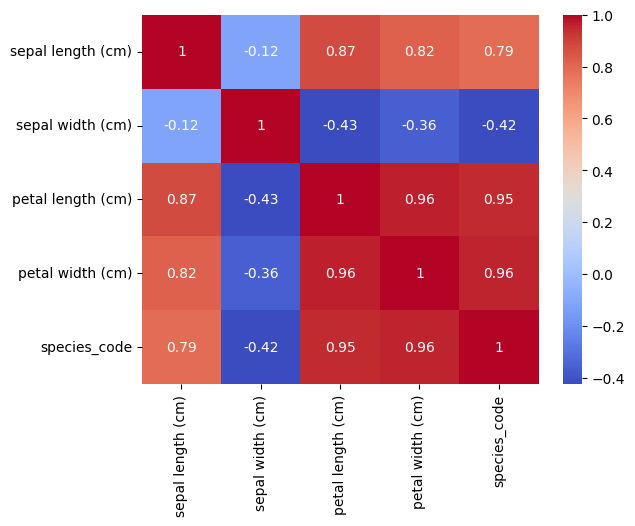

In [64]:
sns.heatmap( df.select_dtypes(exclude='O').corr() , annot=True , cmap='coolwarm') 

In [65]:
# Calculate the correlation matrix for numerical columns
corr_matrix = df.select_dtypes(exclude='O').corr()

In [66]:
corr_matrix['species_code']  # how each numerical feature is correlated with the species_code feature.

sepal length (cm)    0.786971
sepal width (cm)    -0.422987
petal length (cm)    0.949402
petal width (cm)     0.956514
species_code         1.000000
Name: species_code, dtype: float64

In [67]:
# Correlation with target
# not include the species_code featue in cor_matrix
corr_matrix["species_code"].drop("species_code")

sepal length (cm)    0.786971
sepal width (cm)    -0.422987
petal length (cm)    0.949402
petal width (cm)     0.956514
Name: species_code, dtype: float64

#### Find MultiCollinearity b/w Independent Features

In [68]:
# A fun which check the a correaltion among the independent variables
def correlation(df , threshould):
    corr_columns = set()   # A set of columns that have high correlation with each other
    corr_matrix = df.corr()
    for i in  range(0 , len(corr_matrix.columns)):
        for j in range( i ):
            if abs(corr_matrix.iloc[i][j]) > threshould:
                column = corr_matrix.columns[i]
                corr_columns.add(column)
        
    return corr_columns



In [69]:
numerical_columns = df.select_dtypes(exclude="O")
numerical_columns

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [70]:
high_corr_columns = correlation(numerical_columns, 0.90) # collect all the correlated columns
high_corr_columns

C:\Users\ok\AppData\Local\Temp\ipykernel_20444\2758116402.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if abs(corr_matrix.iloc[i][j]) > threshould:


{'petal width (cm)', 'species_code'}

## Checking Class Imbalance

In [71]:
df['target'].value_counts()

target
setosa        50
versicolor    50
virginica     49
Name: count, dtype: int64

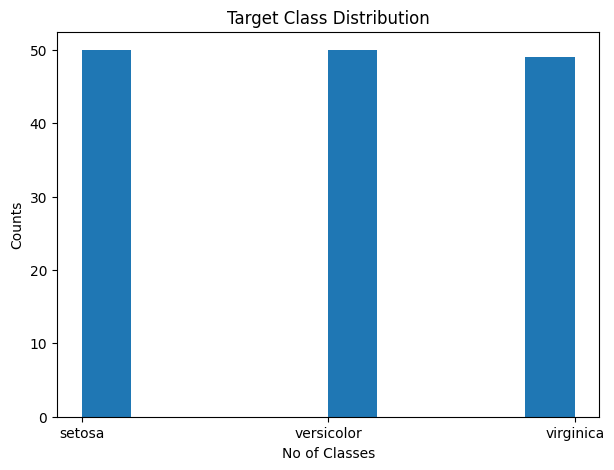

In [72]:
plt.figure(figsize=(7,5))
plt.hist(df['target'])
plt.title('Target Class Distribution')
plt.xlabel("No of Classes")
plt.ylabel("Counts")
plt.show()

### 8.4 Unique Values


In [76]:
df['target'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [77]:
df.nunique()

sepal length (cm)    35
sepal width (cm)     23
petal length (cm)    43
petal width (cm)     22
species_code          3
target                3
dtype: int64

In [78]:
df['petal length (cm)'].unique()

array([1.4, 1.3, 1.5, 1.7, 1.6, 1.1, 1.2, 1. , 1.9, 4.7, 4.5, 4.9, 4. ,
       4.6, 3.3, 3.9, 3.5, 4.2, 3.6, 4.4, 4.1, 4.8, 4.3, 5. , 3.8, 3.7,
       5.1, 3. , 6. , 5.9, 5.6, 5.8, 6.6, 6.3, 6.1, 5.3, 5.5, 6.7, 6.9,
       5.7, 6.4, 5.4, 5.2])

In [79]:
len(df['petal length (cm)'].unique())

43

## Droping Feature

In [80]:
df.drop(columns=['species_code'], inplace = True)

In [81]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


##  Create Independent (X)   and  Dependedent Fature (y)


In [82]:
feature_columns = ["sepal length (cm)", "sepal width (cm)",
                    "petal length (cm)", "petal width (cm)"]

X = df[feature_columns].copy()
y = df["target"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (149, 4)
y shape: (149,)


In [83]:
X.ndim

2

In [84]:
y.ndim

1

In [85]:
X.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [86]:
y.head()


0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: target, dtype: object

## Train test split

In [87]:
from sklearn.model_selection import train_test_split

In [88]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [89]:
X_train.shape, X_test.shape

((119, 4), (30, 4))

In [90]:
print(f"No of samples in training set : {X_train.shape[0]}")

No of samples in training set : 119


In [92]:
print(f"No of samples in test set : {len(X_test)}")

No of samples in test set : 30


In [93]:
y_train

22         setosa
15         setosa
65     versicolor
11         setosa
42         setosa
          ...    
71     versicolor
106     virginica
14         setosa
92     versicolor
102     virginica
Name: target, Length: 119, dtype: object

## Label Encoding

In [94]:

from sklearn.preprocessing import LabelEncoder

In [95]:
encoder = LabelEncoder()

In [96]:
y_train = encoder.fit_transform(y_train)

In [97]:
y_test = encoder.transform(y_test)

In [98]:
y_train

array([0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 0, 0, 1, 2, 2, 1, 2, 1, 2,
       1, 0, 2, 1, 0, 0, 0, 1, 2, 0, 0, 0, 1, 0, 1, 2, 0, 1, 2, 0, 1, 2,
       1, 1, 2, 1, 0, 2, 2, 0, 0, 1, 1, 0, 2, 0, 0, 1, 1, 1, 2, 2, 1, 0,
       0, 2, 2, 0, 0, 0, 1, 2, 0, 2, 2, 0, 1, 1, 2, 1, 2, 0, 2, 1, 2, 1,
       1, 1, 0, 1, 1, 0, 1, 2, 2, 0, 1, 2, 2, 0, 2, 0, 1, 2, 2, 1, 2, 1,
       1, 2, 2, 0, 1, 2, 0, 1, 2])

In [99]:
y_test

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [101]:
# # Check mapping
# print("Class mapping:", dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))

# Logistic Regression

In [102]:
from sklearn.linear_model import LogisticRegression

### creating/instantiating model

In [103]:
logic_model = LogisticRegression()

#### training model

In [104]:

logic_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [105]:
logic_model.classes_

array([0, 1, 2])

#### testing model model on unseen data

In [106]:
y_prediction = logic_model.predict(X_test)

In [107]:
y_prediction

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

## Model Evaluation

In [108]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

In [109]:
accuracy_score(y_test, y_prediction)

1.0

In [110]:
precision_score(y_test, y_prediction, average='macro')

1.0

In [111]:
recall_score(y_test, y_prediction, average='macro')

1.0

In [112]:
confusion_matrix(y_test, y_prediction)

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

In [113]:
len(y_test)

30

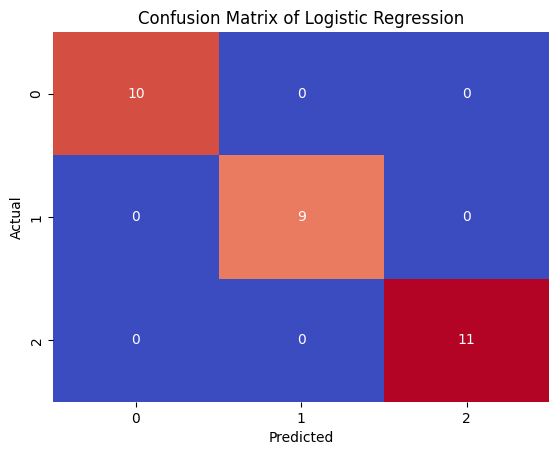

In [114]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_prediction)

# Plot heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm', cbar=False)
plt.title("Confusion Matrix of Logistic Regression")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [115]:
print(classification_report(y_test, y_prediction))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# Random Forest

In [116]:
from sklearn.ensemble import RandomForestClassifier

In [117]:
rf_classifier = RandomForestClassifier()

In [118]:
rf_classifier.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Make Predictions on Unseen Data

In [119]:
y_rf_predctions = rf_classifier.predict(X_test)

In [120]:
y_rf_predctions

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

### Model Evaluation

#### **Accuracy**

In [121]:
accuracy_score(y_test, y_rf_predctions)

1.0

### **Precision**

In [122]:
precision_score(y_test, y_rf_predctions, average='macro')

1.0

#### **Recall**

In [123]:
recall_score(y_test, y_rf_predctions, average='macro')

1.0

#### **Confusion Matrix**

In [124]:
confusion_matrix(y_test, y_rf_predctions)

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

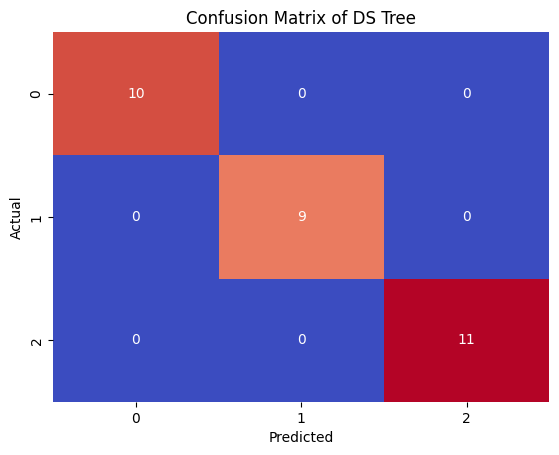

In [125]:
sns.heatmap(confusion_matrix(y_test, y_rf_predctions), fmt='d', annot=True, cmap='coolwarm', cbar=False)
plt.title(f"Confusion Matrix of DS Tree")
plt.xlabel("Predicted")
plt.ylabel('Actual')
plt.show()

# Training Multiple Algorithms And Selecing Best one

In [126]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix , precision_score, recall_score, f1_score


In [127]:
models = {
    "Logistic Reg"  : LogisticRegression(),
    "Decision Tree" : DecisionTreeClassifier(),
    "SVM"           : SVC(),
    "Random Forest" : RandomForestClassifier(),
    "AdaBoost":       AdaBoostClassifier()
    
}



for name , model in models.items():
    # Training model
    model.fit(X_train, y_train)

    # Make Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    # Training set Performance
    model_train_accuracy = accuracy_score(y_train ,  y_train_pred)
    model_test_accuracy  = accuracy_score(y_test , y_test_pred)


    print(f"Model Name :  {name}")
    
    print('Model Performance for Training set')
    print(f"Training Accuracy : {model_train_accuracy}")

    print("\nModel Testing")
    print(f"Model Test Accuracy : {model_test_accuracy}")
    print("\n")
    print("=" * 50) 

    

Model Name :  Logistic Reg
Model Performance for Training set
Training Accuracy : 0.9663865546218487

Model Testing
Model Test Accuracy : 1.0


Model Name :  Decision Tree
Model Performance for Training set
Training Accuracy : 1.0

Model Testing
Model Test Accuracy : 1.0


Model Name :  SVM
Model Performance for Training set
Training Accuracy : 0.9663865546218487

Model Testing
Model Test Accuracy : 1.0


Model Name :  Random Forest
Model Performance for Training set
Training Accuracy : 1.0

Model Testing
Model Test Accuracy : 1.0


Model Name :  AdaBoost
Model Performance for Training set
Training Accuracy : 1.0

Model Testing
Model Test Accuracy : 0.9333333333333333




# Hyperparamter Tuning

### **GridSearchCV**

In [128]:
from sklearn.model_selection import GridSearchCV

In [129]:

parameter_grid = {
    "n_estimators": [50, 100],       # number of trees
    "max_depth": [None, 5, 10]      # depth of each tree
}

In [130]:
# info
possible_combinations = len(parameter_grid['n_estimators']) * len(parameter_grid['max_depth'])
print(f"Total Possible Combinations { possible_combinations}")

Total Possible Combinations 6


In [137]:
gd_classifier = GridSearchCV(
    estimator=RandomForestClassifier(),  # rf_classifier
    param_grid= parameter_grid,
    cv=3,
    n_jobs= -1 ,  # Use full cpu cores
    verbose= 1 # show details

)

In [138]:
gd_classifier.fit(X_train, y_train)

Fitting 3 folds for each of 6 candidates, totalling 18 fits


,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': [None, 5, ...], 'n_estimators': [50, 100]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [139]:
print("Total number of models that will be trained is : Combinations * CV_Size")
print(f"                                               :{possible_combinations * 3}")   # here 3 is the cv


Total number of models that will be trained is : Combinations * CV_Size
                                               :18


In [140]:
gd_classifier.best_estimator_

,n_estimators,50
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [141]:
gd_classifier.best_params_

{'max_depth': 5, 'n_estimators': 50}

In [142]:
gd_classifier.best_score_

np.float64(0.9581196581196582)

#### **Make Predictions**

In [143]:
y_prediction_dg = gd_classifier.predict(X_test)

In [144]:
y_prediction_dg

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

### Evaulation

In [145]:
accuracy_score(y_test, y_prediction_dg)

1.0

In [146]:
precision_score(y_test, y_prediction_dg, average="macro")

1.0

In [147]:
recall_score(y_test, y_prediction_dg, average="macro")

1.0

In [148]:
confusion_matrix(y_test,y_prediction_dg)

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

### **RandomizedSearchCV**

In [150]:
from sklearn.model_selection import RandomizedSearchCV

In [151]:
parameter_dist = {
    "n_estimators": [50, 100],       # number of trees
    "max_depth": [None, 5, 10]      # depth of each tree
}

In [152]:
rm_classifier = RandomizedSearchCV(
    estimator= rf_classifier,
    param_distributions= parameter_dist,
    cv= 3,
    n_jobs= -1,
    verbose= 1
)

In [153]:
rm_classifier.fit(X_train, y_train)

c:\Users\ok\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 6 candidates, totalling 18 fits


,estimator,RandomForestClassifier()
,param_distributions,"{'max_depth': [None, 5, ...], 'n_estimators': [50, 100]}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [154]:
# rm_classifier.n_iter

In [162]:
# n_iter   how many random parameter combinations will be tested.
n_iter= 4
cv = 3

rm_classifier = RandomizedSearchCV(
    estimator= rf_classifier,
    param_distributions= parameter_dist,
    n_iter= n_iter,  # default value is 10
    cv= cv,
    n_jobs= -1,
    verbose= 1
)

In [163]:
rm_classifier.fit(X_train, y_train)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


,estimator,RandomForestClassifier()
,param_distributions,"{'max_depth': [None, 5, ...], 'n_estimators': [50, 100]}"
,n_iter,4
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [165]:
print(f"Total trainable models : { n_iter * cv}")

Total trainable models : 12


In [166]:
rm_classifier.best_estimator_

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [167]:
rm_classifier.best_params_

{'n_estimators': 100, 'max_depth': 5}

In [168]:
rm_classifier.best_score_

np.float64(0.9581196581196582)

In [169]:
rm_classifier.best_index_

np.int64(0)

In [174]:
model = RandomForestClassifier(n_estimators = 100, max_depth = 5)

## Saving Model

In [177]:
import pickle

In [178]:
with open("model.pkl", "wb") as file:
    pickle.dump(best_rf, file)

## loading model

In [179]:
with open("model.pkl", "rb") as file:
    model = pickle.load(file)

In [180]:
model

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [181]:
df.iloc[1, : ]

sepal length (cm)       4.9
sepal width (cm)        3.0
petal length (cm)       1.4
petal width (cm)        0.2
target               setosa
Name: 1, dtype: object

In [182]:
model.predict([[4.9, 3.0,1.4, 0.2]])

c:\Users\ok\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([0])